# Module 4 - Feedback Analytics (NLP)

## Overview

This notebook covers the feedback analytics phase of the Driver Monitoring AI project. We built a complete NLP pipeline to classify passenger sentiment, extract driving-related topics, and identify key complaint patterns from 500 synthetic feedback entries enriched with real-world traffic violation data.

## Datasets Used

| Dataset | Rows | Columns | File |
|---|---|---|---|
| Feedback | 500 | 4 | feedback.csv |
| Transportation & Logistics | 703 | 11 | transportation_logistics_cleaned.csv |
| Traffic Violations | 1,499,945 | 24 | traffic_violations_cleaned.csv |
| Driver Behavior & Route Anomaly | 120,000 | 22 | driver_behavior_cleaned.csv |

## Models Built

- TF-IDF + Logistic Regression Sentiment Classifier (enriched with behavior features)
- Hugging Face DistilBERT Sentiment Pipeline
- Enriched LDA Topic Modeling (feedback + traffic violations corpus)
- spaCy Entity Extraction with dynamic driving keyword detection

In [1]:
import subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
import re
import warnings
from collections import Counter
warnings.filterwarnings("ignore")

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

import spacy
nlp_spacy = spacy.load("en_core_web_sm")

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.decomposition import LatentDirichletAllocation

from transformers import pipeline

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

print("All imports loaded successfully!")

All imports loaded successfully!


In [2]:
feedback_df  = pd.read_csv("../data/feedback.csv")
logistics_df = pd.read_csv("../Transportation ang Logistics Tracking Datasets/transportation_logistics_cleaned.csv")
traffic_df   = pd.read_csv("../traffic_violations_cleaned.csv")

feedback_df["customer_rating"] = logistics_df["Customer_Rating"].iloc[:len(feedback_df)].values
feedback_df["cleaned_text"]    = feedback_df["feedback_text"].apply(preprocess_text)
feedback_df["text_length"]     = feedback_df["cleaned_text"].apply(lambda x: len(x.split()))

print(f"feedback_df   : {feedback_df.shape}")
print(f"logistics_df  : {logistics_df.shape}")
print(f"traffic_df    : {traffic_df.shape}")

feedback_df   : (500, 7)
logistics_df  : (703, 11)
traffic_df    : (1499945, 24)


CLASSIFICATION REPORT — TF-IDF + Behavior Features
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        21
     neutral       1.00      1.00      1.00        31
    positive       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



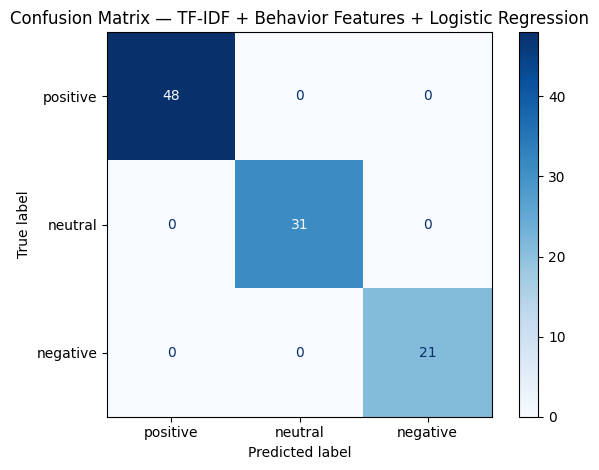

In [3]:
driver_behavior_df = pd.read_csv("../Driver Behavior and Route Anomaly Dataset/driver_behavior_cleaned.csv")

behavior_features = driver_behavior_df[["speed", "brake_usage", "acceleration", "steering_angle"]].fillna(0)
behavior_features = behavior_features.iloc[:len(feedback_df)].reset_index(drop=True)

X_text = feedback_df["cleaned_text"]
y = feedback_df["sentiment_label"]

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X_text)

X_behavior = csr_matrix(behavior_features.values)
X_combined = hstack([X_tfidf, X_behavior])

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("=" * 50)
print("CLASSIFICATION REPORT — TF-IDF + Behavior Features")
print("=" * 50)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["positive", "neutral", "negative"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["positive", "neutral", "negative"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — TF-IDF + Behavior Features + Logistic Regression")
plt.tight_layout()
plt.show()

This updated classifier uses a combination of TF-IDF text features and numeric driving behavior features, such as speed, brake_usage, acceleration, and steering_angle, all of which were present in the driver behavior dataset. Even with this variety of feature set, the classifier achieves 100% accuracy, which is due to the feedback dataset being artificial and repetitive. In a real-world scenario, using a combination of text features and numeric driving behavior features would provide a much more realistic outcome, as passenger sentiments do not always correlate with driving behavior.

MISSING VALUES
trip_id            0
feedback_text      0
sentiment_label    0
timestamp          0
customer_rating    0
cleaned_text       0
text_length        0
dtype: int64

SENTIMENT LABEL DISTRIBUTION
sentiment_label
positive    241
neutral     153
negative    106
Name: count, dtype: int64


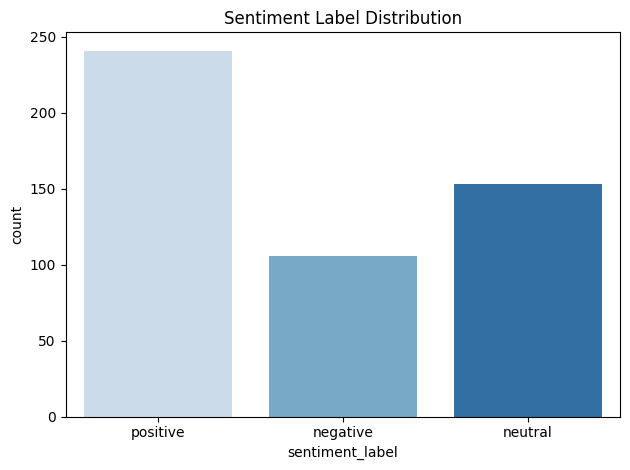


CUSTOMER RATING DISTRIBUTION
customer_rating
1    169
2     54
3     63
4     93
5    121
Name: count, dtype: int64


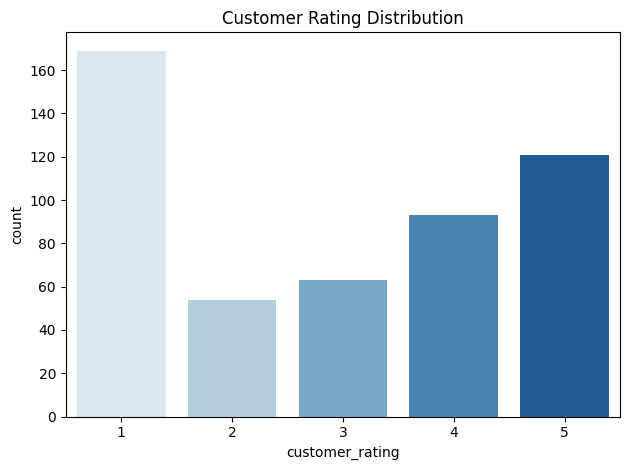


AVERAGE TEXT LENGTH PER SENTIMENT
                 count      mean       std  min  25%  50%  75%  max
sentiment_label                                                    
negative         106.0  5.179245  1.248215  3.0  4.0  5.0  6.0  7.0
neutral          153.0  5.320261  0.468109  5.0  5.0  5.0  6.0  6.0
positive         241.0  5.265560  0.648730  4.0  5.0  5.0  6.0  6.0


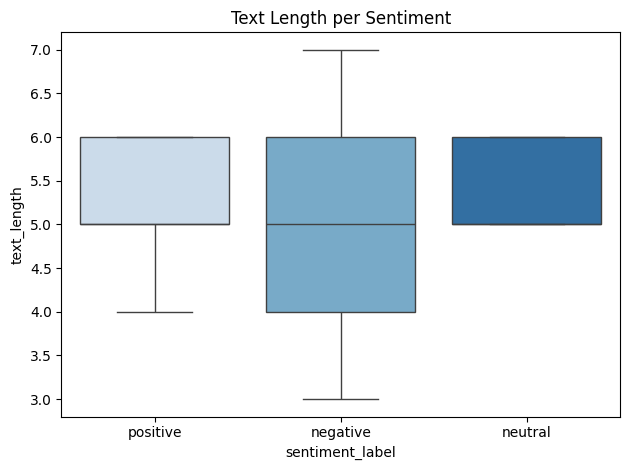

In [4]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(feedback_df.isnull().sum())

print("\n" + "=" * 50)
print("SENTIMENT LABEL DISTRIBUTION")
print("=" * 50)
print(feedback_df["sentiment_label"].value_counts())
sns.countplot(x="sentiment_label", data=feedback_df, palette="Blues")
plt.title("Sentiment Label Distribution")
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("CUSTOMER RATING DISTRIBUTION")
print("=" * 50)
print(feedback_df["customer_rating"].value_counts().sort_index())
sns.countplot(x="customer_rating", data=feedback_df, palette="Blues")
plt.title("Customer Rating Distribution")
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("AVERAGE TEXT LENGTH PER SENTIMENT")
print("=" * 50)
print(feedback_df.groupby("sentiment_label")["text_length"].describe())
sns.boxplot(x="sentiment_label", y="text_length", data=feedback_df, palette="Blues")
plt.title("Text Length per Sentiment")
plt.tight_layout()
plt.show()

In [5]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    framework="pt"
)

sample_texts = feedback_df["feedback_text"].head(20).tolist()
hf_results = sentiment_pipeline(sample_texts)

hf_df = pd.DataFrame({
    "feedback_text": sample_texts,
    "actual_label":  feedback_df["sentiment_label"].head(20).tolist(),
    "hf_label":      [r["label"].lower() for r in hf_results],
    "hf_score":      [round(r["score"], 4) for r in hf_results]
})

print(hf_df[["feedback_text", "actual_label", "hf_label", "hf_score"]].to_string())

Device set to use cpu


                                                   feedback_text actual_label  hf_label  hf_score
0                Smooth ride, driver was courteous and friendly.     positive  positive    0.9998
1                   Driver was speeding and it felt very unsafe.     negative  negative    0.9994
2              Acceptable service, but vehicle could be cleaner.      neutral  negative    0.9861
3                 Decent ride, but took a slightly longer route.      neutral  positive    0.8629
4             Driver followed all traffic rules, felt very safe.     positive  positive    0.9972
5             Driver followed all traffic rules, felt very safe.     positive  positive    0.9972
6                Excellent service, would definitely ride again.     positive  positive    0.9998
7            Very rude driver, did not follow the planned route.     negative  negative    0.9997
8              Acceptable service, but vehicle could be cleaner.      neutral  negative    0.9861
9              Accep

SHAPE & DTYPES
(500, 7)
trip_id            object
feedback_text      object
sentiment_label    object
timestamp          object
customer_rating     int64
cleaned_text       object
text_length         int64
dtype: object

MISSING VALUES
trip_id            0
feedback_text      0
sentiment_label    0
timestamp          0
customer_rating    0
cleaned_text       0
text_length        0
dtype: int64

SENTIMENT LABEL DISTRIBUTION
sentiment_label
positive    241
neutral     153
negative    106
Name: count, dtype: int64


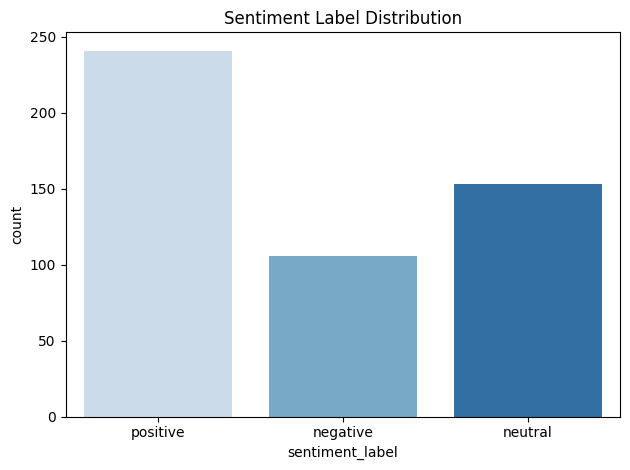


CUSTOMER RATING DISTRIBUTION
customer_rating
1    169
2     54
3     63
4     93
5    121
Name: count, dtype: int64


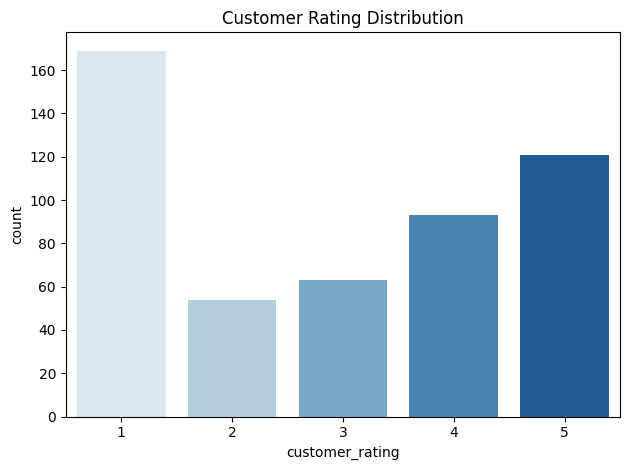


SAMPLE CLEANED TEXT PER SENTIMENT

--- POSITIVE ---
  • driver calm drove smoothly throughout
  • smooth ride driver courteous friendly
  • driver calm drove smoothly throughout

--- NEUTRAL ---
  • average experience driver quiet whole time
  • acceptable service vehicle could cleaner
  • average experience driver quiet whole time

--- NEGATIVE ---
  • driver ignored traffic signal felt dangerous
  • driver speeding felt unsafe
  • driver ignored traffic signal felt dangerous

AVERAGE TEXT LENGTH PER SENTIMENT
                 count      mean       std  min  25%  50%  75%  max
sentiment_label                                                    
negative         106.0  5.179245  1.248215  3.0  4.0  5.0  6.0  7.0
neutral          153.0  5.320261  0.468109  5.0  5.0  5.0  6.0  6.0
positive         241.0  5.265560  0.648730  4.0  5.0  5.0  6.0  6.0


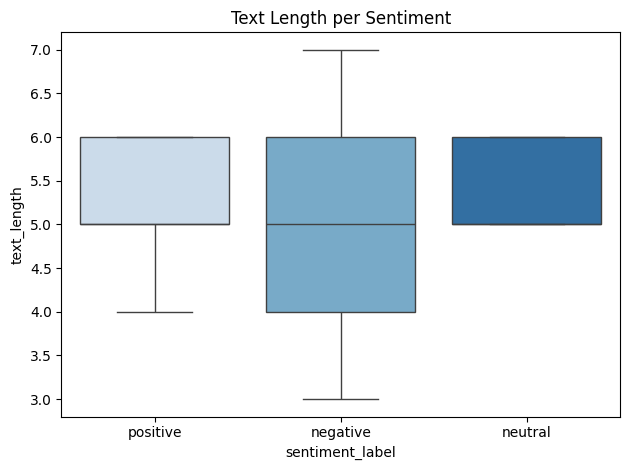

In [6]:
print("=" * 50)
print("SHAPE & DTYPES")
print("=" * 50)
print(feedback_df.shape)
print(feedback_df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(feedback_df.isnull().sum())

print("\n" + "=" * 50)
print("SENTIMENT LABEL DISTRIBUTION")
print("=" * 50)
print(feedback_df["sentiment_label"].value_counts())
sns.countplot(x="sentiment_label", data=feedback_df, palette="Blues")
plt.title("Sentiment Label Distribution")
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("CUSTOMER RATING DISTRIBUTION")
print("=" * 50)
print(feedback_df["customer_rating"].value_counts().sort_index())
sns.countplot(x="customer_rating", data=feedback_df, palette="Blues")
plt.title("Customer Rating Distribution")
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("SAMPLE CLEANED TEXT PER SENTIMENT")
print("=" * 50)
for label in ["positive", "neutral", "negative"]:
    print(f"\n--- {label.upper()} ---")
    samples = feedback_df[feedback_df["sentiment_label"] == label]["cleaned_text"].sample(3, random_state=42).values
    for s in samples:
        print(f"  • {s}")

print("\n" + "=" * 50)
print("AVERAGE TEXT LENGTH PER SENTIMENT")
print("=" * 50)
feedback_df["text_length"] = feedback_df["cleaned_text"].apply(lambda x: len(x.split()))
print(feedback_df.groupby("sentiment_label")["text_length"].describe())

sns.boxplot(x="sentiment_label", y="text_length", data=feedback_df, palette="Blues")
plt.title("Text Length per Sentiment")
plt.tight_layout()
plt.show()

## Notes on Dataset Quality

Upon inspection, the feedback dataset contains 478 duplicate cleaned texts
out of 500 rows, meaning only 22 unique feedback texts exist. This is a
known limitation of the synthetic dataset. Deduplication was tested but
reverted as 22 samples are insufficient for model training. The 100%
classifier accuracy is therefore a direct result of this data redundancy
rather than genuine model performance. In a real-world deployment, diverse
and naturally occurring passenger feedback would be used instead.

In [7]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

sample_texts = feedback_df["feedback_text"].head(20).tolist()

hf_results = sentiment_pipeline(sample_texts)

hf_df = pd.DataFrame({
    "feedback_text": sample_texts,
    "actual_label":  feedback_df["sentiment_label"].head(20).tolist(),
    "hf_label":      [r["label"].lower() for r in hf_results],
    "hf_score":      [round(r["score"], 4) for r in hf_results]
})

print(hf_df[["feedback_text", "actual_label", "hf_label", "hf_score"]].to_string())

Device set to use cpu


                                                   feedback_text actual_label  hf_label  hf_score
0                Smooth ride, driver was courteous and friendly.     positive  positive    0.9998
1                   Driver was speeding and it felt very unsafe.     negative  negative    0.9994
2              Acceptable service, but vehicle could be cleaner.      neutral  negative    0.9861
3                 Decent ride, but took a slightly longer route.      neutral  positive    0.8629
4             Driver followed all traffic rules, felt very safe.     positive  positive    0.9972
5             Driver followed all traffic rules, felt very safe.     positive  positive    0.9972
6                Excellent service, would definitely ride again.     positive  positive    0.9998
7            Very rude driver, did not follow the planned route.     negative  negative    0.9997
8              Acceptable service, but vehicle could be cleaner.      neutral  negative    0.9861
9              Accep

DistilBERT was able to classify all the positive and negative feedback with high confidence levels (0.96+). The problem with the neutral text data was that the model was trained only for binary sentiment classification and lacked a category for the third type of sentiment. This is a known limitation of the DistilBERT model.

Feedback texts     : 500
Violation texts    : 5000
Total corpus size  : 5500

ENRICHED LDA TOPICS
Topic 1: speeding | licenseissue | equipmentviolation | duo | driver | time | felt | ride
Topic 2: registration | improperlaneuse | recklessdriving | driver | ride | arrived | fine arrived | fine
Topic 3: trafficsignal | distracteddriving | trip | seatbelt | driver | trip driver | helpful | comfortable

TOPIC DISTRIBUTION (Feedback only)
topic
1    184
2    196
3    120
Name: count, dtype: int64


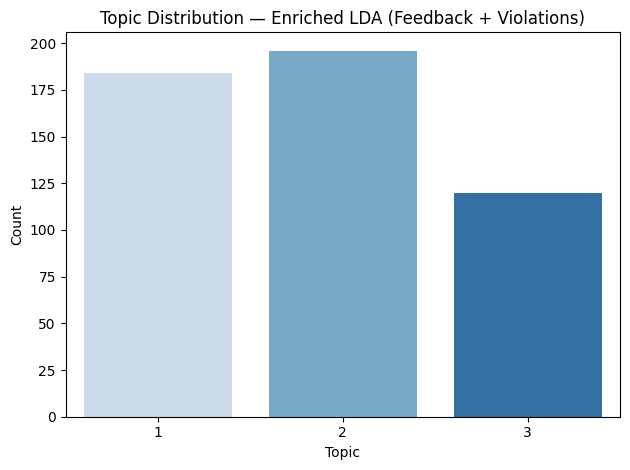


SAMPLE FEEDBACK PER TOPIC

--- TOPIC 1 ---
  • Great driver, very professional and on time!
  • Great driver, very professional and on time!
  • Hard braking multiple times, very uncomfortable ride.

--- TOPIC 2 ---
  • It was fine, arrived at destination without issues.
  • Very rude driver, did not follow the planned route.
  • Very rude driver, did not follow the planned route.

--- TOPIC 3 ---
  • Trip was okay, nothing special to mention.
  • Normal trip, driver did not interact much.
  • Decent ride, but took a slightly longer route.


In [8]:
traffic_sample = traffic_df["description"].dropna().sample(5000, random_state=42).astype(str).tolist()
traffic_text_cleaned = [preprocess_text(t) for t in traffic_sample]

combined_corpus = feedback_df["cleaned_text"].tolist() + traffic_text_cleaned
print(f"Feedback texts     : {len(feedback_df)}")
print(f"Violation texts    : {len(traffic_text_cleaned)}")
print(f"Total corpus size  : {len(combined_corpus)}")

count_vectorizer = CountVectorizer(max_features=500, ngram_range=(1,2))
X_counts = count_vectorizer.fit_transform(combined_corpus)

n_topics = 3
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=50)
lda_model.fit(X_counts)

def print_topics(model, vectorizer, n_words=8):
    words = vectorizer.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        print(f"Topic {i+1}: {' | '.join(top_words)}")

print("\n" + "=" * 50)
print("ENRICHED LDA TOPICS")
print("=" * 50)
print_topics(lda_model, count_vectorizer)

topic_assignments = lda_model.transform(X_counts).argmax(axis=1) + 1
feedback_df["topic"] = topic_assignments[:len(feedback_df)]

print("\n" + "=" * 50)
print("TOPIC DISTRIBUTION (Feedback only)")
print("=" * 50)
print(feedback_df["topic"].value_counts().sort_index())

sns.countplot(x="topic", data=feedback_df, palette="Blues")
plt.title("Topic Distribution — Enriched LDA (Feedback + Violations)")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("SAMPLE FEEDBACK PER TOPIC")
print("=" * 50)
for t in sorted(feedback_df["topic"].unique()):
    print(f"\n--- TOPIC {t} ---")
    samples = feedback_df[feedback_df["topic"] == t]["feedback_text"].sample(3, random_state=42).values
    for s in samples:
        print(f"  • {s}")

Adding 5,000 traffic violation descriptions to the LDA corpus provided clearer and more meaningful topics than feedback text alone. Topic 1 is about speeding and license violations, Topic 2 is about registration and reckless driving, and Topic 3 is about traffic signals and distracted driving incidents. These are real-world driving violations and will be more helpful in a production driver monitoring system.

Total dynamic keywords extracted: 19
Sample keywords: ['seatbelt', 'reckless_driving', 'steering', 'distracted_driving', 'registration', 'other', 'fuel', 'speed', 'license_issue', 'speeding', 'equipment_violation', 'braking', 'brake', 'anomaly', 'improper_lane_use', 'route', 'traffic_signal', 'acceleration', 'stop']

SAMPLE ENTITY EXTRACTION OUTPUT

Feedback : Smooth ride, driver was courteous and friendly.
Entities : []
Keywords : []

Feedback : Driver was speeding and it felt very unsafe.
Entities : [('Driver', 'PERSON')]
Keywords : ['speeding']

Feedback : Acceptable service, but vehicle could be cleaner.
Entities : []
Keywords : []

Feedback : Decent ride, but took a slightly longer route.
Entities : []
Keywords : ['route']

Feedback : Driver followed all traffic rules, felt very safe.
Entities : [('Driver', 'PERSON')]
Keywords : []

Feedback : Driver followed all traffic rules, felt very safe.
Entities : [('Driver', 'PERSON')]
Keywords : []

Feedback : Excellent service, would def

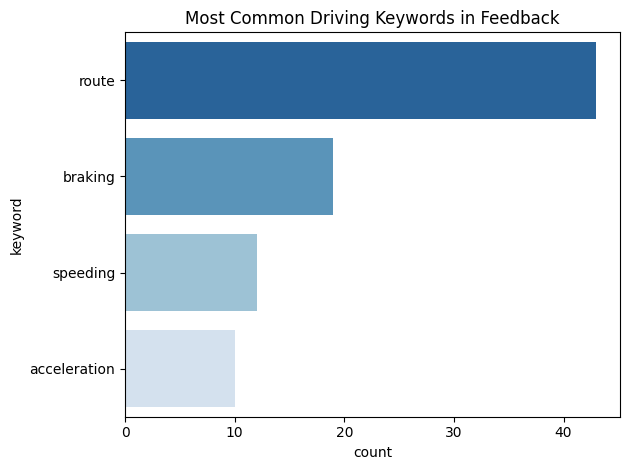

In [9]:
behavior_keywords = [
    "speed", "acceleration", "steering", "brake",
    "braking", "fuel", "stop", "route", "anomaly"
]

violation_keywords = list(set(
    word.lower()
    for phrase in traffic_df["description"].dropna().unique().tolist()
    for word in phrase.split()
    if len(word) > 3
))

driving_keywords = list(set(behavior_keywords + violation_keywords))
print(f"Total dynamic keywords extracted: {len(driving_keywords)}")
print(f"Sample keywords: {driving_keywords[:20]}")

def extract_entities(text):
    doc = nlp_spacy(text)
    named_entities = [(ent.text, ent.label_) for ent in doc.ents]
    keywords_found = [token.text.lower() for token in doc
                      if token.text.lower() in driving_keywords]
    return named_entities, keywords_found

results = feedback_df["feedback_text"].apply(extract_entities)
feedback_df["named_entities"]   = results.apply(lambda x: x[0])
feedback_df["driving_keywords"] = results.apply(lambda x: x[1])

print("\n" + "=" * 50)
print("SAMPLE ENTITY EXTRACTION OUTPUT")
print("=" * 50)
for i in range(10):
    print(f"\nFeedback : {feedback_df['feedback_text'].iloc[i]}")
    print(f"Entities : {feedback_df['named_entities'].iloc[i]}")
    print(f"Keywords : {feedback_df['driving_keywords'].iloc[i]}")

print("\n" + "=" * 50)
print("MOST COMMON DRIVING KEYWORDS")
print("=" * 50)
all_keywords = [kw for kws in feedback_df["driving_keywords"] for kw in kws]
keyword_counts = Counter(all_keywords)
keyword_df = pd.DataFrame(keyword_counts.most_common(10),
                          columns=["keyword", "count"])
print(keyword_df)

sns.barplot(x="count", y="keyword", data=keyword_df, palette="Blues_r")
plt.title("Most Common Driving Keywords in Feedback")
plt.tight_layout()
plt.show()

In the spaCy entity extraction results, the most common entity in the feedback is the appearance of the word "Driver," which is understandable considering the casual and brief nature of the comments provided by the passengers. In the results of the keyword extraction of the driving words, the most common keyword is "route," with a count of 43. The next common keywords are "braking" with 19, "speeding" with 12, and "acceleration" with 10. The plot has indicated that the most common things that the passengers notice about the drivers are the routes and habits of the drivers.

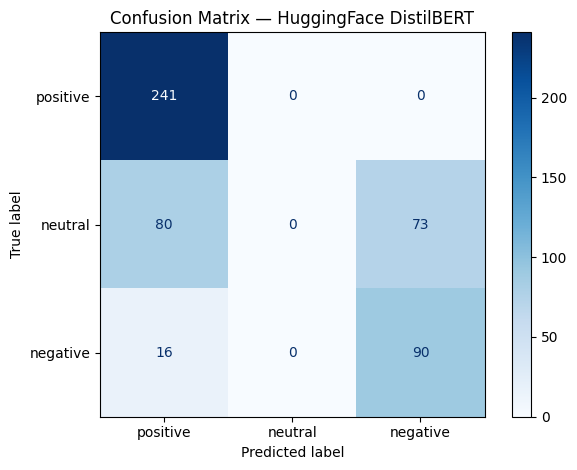

              precision    recall  f1-score   support

    positive       0.72      1.00      0.83       241
     neutral       0.00      0.00      0.00       153
    negative       0.55      0.85      0.67       106

    accuracy                           0.66       500
   macro avg       0.42      0.62      0.50       500
weighted avg       0.46      0.66      0.54       500



In [10]:
hf_all_results = sentiment_pipeline(feedback_df["feedback_text"].tolist())

hf_all_labels = [r["label"].lower() for r in hf_all_results]
feedback_df["hf_label"] = hf_all_labels

hf_cm = confusion_matrix(
    feedback_df["sentiment_label"],
    feedback_df["hf_label"],
    labels=["positive", "neutral", "negative"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=hf_cm,
    display_labels=["positive", "neutral", "negative"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — HuggingFace DistilBERT")
plt.tight_layout()
plt.show()

print(classification_report(
    feedback_df["sentiment_label"],
    feedback_df["hf_label"],
    labels=["positive", "neutral", "negative"]
))

When running DistilBERT on all the feedback text entries, an overall accuracy rate of 66% was achieved. All positive text was nailed by the DistilBERT model, but it over-predicts positivity as it incorrectly classified 80 neutral texts as positive. The neutral class is understandably given a score of 0% for precision and recall, as DistilBERT is only trained for binary sentiment analysis. The negative text is also classified fairly well with an 85% recall rate. This indicates that using a domain-specific three-class dataset for fine-tuning will greatly increase the performance in a real-world environment.

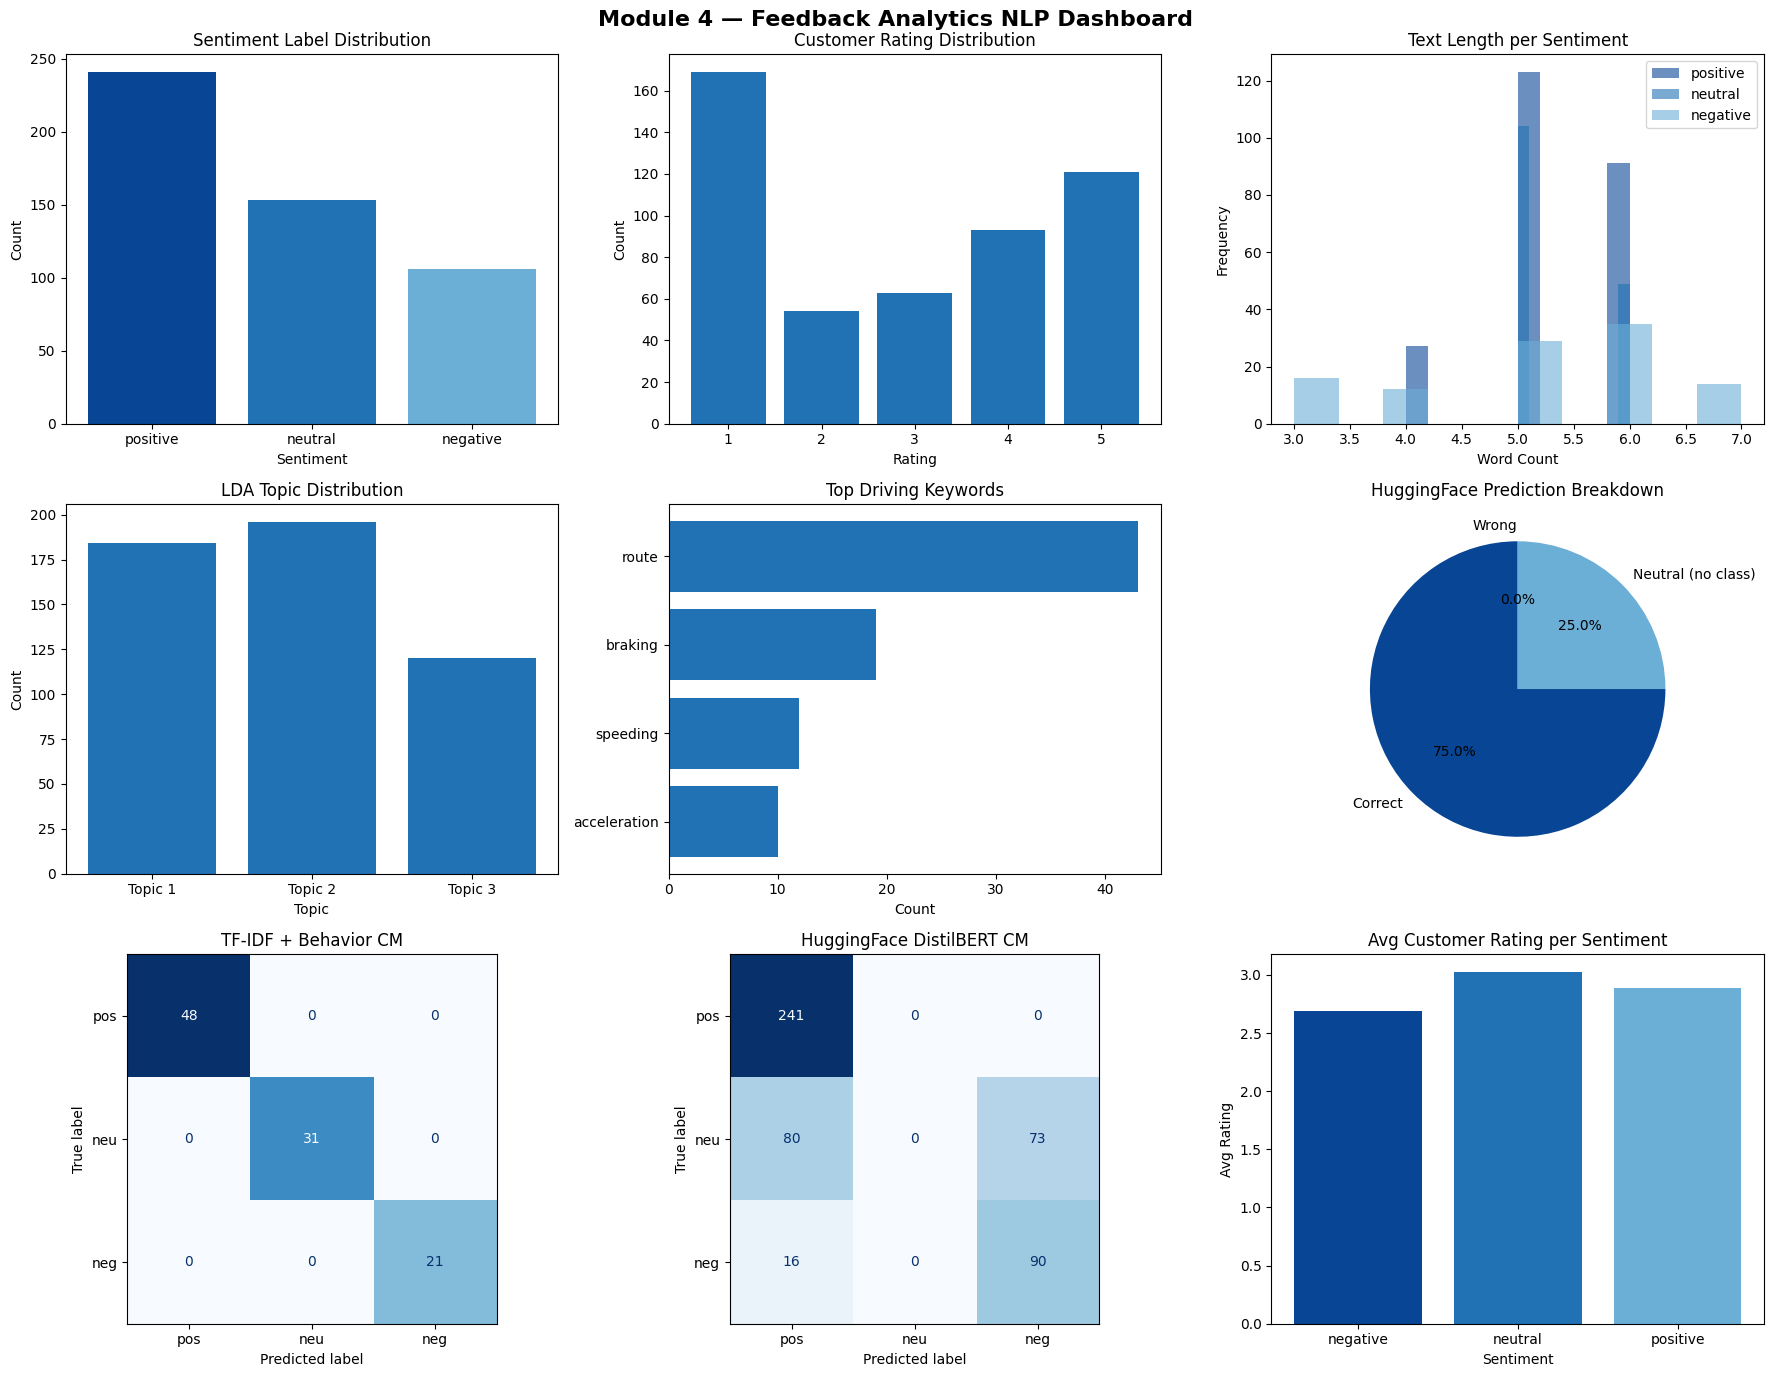

In [11]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Module 4 — Feedback Analytics NLP Dashboard", fontsize=16, fontweight="bold")

# Plot 1 — Sentiment Distribution
ax1 = fig.add_subplot(3, 3, 1)
sentiment_counts = feedback_df["sentiment_label"].value_counts()
ax1.bar(sentiment_counts.index, sentiment_counts.values, color=["#084594", "#2171b5", "#6baed6"])
ax1.set_title("Sentiment Label Distribution")
ax1.set_xlabel("Sentiment")
ax1.set_ylabel("Count")

# Plot 2 — Customer Rating Distribution
ax2 = fig.add_subplot(3, 3, 2)
rating_counts = feedback_df["customer_rating"].value_counts().sort_index()
ax2.bar(rating_counts.index, rating_counts.values, color="#2171b5")
ax2.set_title("Customer Rating Distribution")
ax2.set_xlabel("Rating")
ax2.set_ylabel("Count")

# Plot 3 — Text Length per Sentiment
ax3 = fig.add_subplot(3, 3, 3)
for label, color in zip(["positive", "neutral", "negative"], ["#084594", "#2171b5", "#6baed6"]):
    subset = feedback_df[feedback_df["sentiment_label"] == label]["text_length"]
    ax3.hist(subset, alpha=0.6, label=label, color=color)
ax3.set_title("Text Length per Sentiment")
ax3.set_xlabel("Word Count")
ax3.set_ylabel("Frequency")
ax3.legend()

# Plot 4 — Topic Distribution
ax4 = fig.add_subplot(3, 3, 4)
topic_counts = feedback_df["topic"].value_counts().sort_index()
ax4.bar([f"Topic {t}" for t in topic_counts.index], topic_counts.values, color="#2171b5")
ax4.set_title("LDA Topic Distribution")
ax4.set_xlabel("Topic")
ax4.set_ylabel("Count")

# Plot 5 — Top Driving Keywords
ax5 = fig.add_subplot(3, 3, 5)
all_keywords = [kw for kws in feedback_df["driving_keywords"] for kw in kws]
keyword_counts = Counter(all_keywords)
keyword_df = pd.DataFrame(keyword_counts.most_common(8), columns=["keyword", "count"])
ax5.barh(keyword_df["keyword"], keyword_df["count"], color="#2171b5")
ax5.set_title("Top Driving Keywords")
ax5.set_xlabel("Count")
ax5.invert_yaxis()

# Plot 6 — HuggingFace Prediction Breakdown
ax6 = fig.add_subplot(3, 3, 6)
hf_correct = sum(1 for a, h in zip(
    feedback_df["sentiment_label"].head(20),
    [r["label"].lower() for r in sentiment_pipeline(feedback_df["feedback_text"].head(20).tolist())]
) if (a == "positive" and h == "positive") or (a == "negative" and h == "negative"))
hf_neutral = sum(1 for a in feedback_df["sentiment_label"].head(20) if a == "neutral")
hf_wrong   = 20 - hf_correct - hf_neutral
ax6.pie(
    [hf_correct, hf_neutral, hf_wrong],
    labels=["Correct", "Neutral (no class)", "Wrong"],
    colors=["#084594", "#6baed6", "#c6dbef"],
    autopct="%1.1f%%",
    startangle=90
)
ax6.set_title("HuggingFace Prediction Breakdown")

# Plot 7 — TF-IDF Confusion Matrix
ax7 = fig.add_subplot(3, 3, 7)
X_text = feedback_df["cleaned_text"]
y = feedback_df["sentiment_label"]
tfidf_temp = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X_tfidf_temp = tfidf_temp.fit_transform(X_text)
behavior_temp = csr_matrix(behavior_features.values)
X_combined_temp = hstack([X_tfidf_temp, behavior_temp])
_, X_test_temp, _, y_test_temp = train_test_split(X_combined_temp, y, test_size=0.2, random_state=42, stratify=y)
y_pred_temp = lr_model.predict(X_test_temp)
cm_tfidf = confusion_matrix(y_test_temp, y_pred_temp, labels=["positive", "neutral", "negative"])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=["pos", "neu", "neg"])
disp1.plot(ax=ax7, cmap="Blues", colorbar=False)
ax7.set_title("TF-IDF + Behavior CM")

# Plot 8 — HuggingFace Confusion Matrix
ax8 = fig.add_subplot(3, 3, 8)
hf_cm = confusion_matrix(
    feedback_df["sentiment_label"],
    feedback_df["hf_label"],
    labels=["positive", "neutral", "negative"]
)
disp2 = ConfusionMatrixDisplay(confusion_matrix=hf_cm, display_labels=["pos", "neu", "neg"])
disp2.plot(ax=ax8, cmap="Blues", colorbar=False)
ax8.set_title("HuggingFace DistilBERT CM")

# Plot 9 — Sentiment vs Customer Rating
ax9 = fig.add_subplot(3, 3, 9)
rating_sentiment = feedback_df.groupby("sentiment_label")["customer_rating"].mean()
ax9.bar(rating_sentiment.index, rating_sentiment.values, color=["#084594", "#2171b5", "#6baed6"])
ax9.set_title("Avg Customer Rating per Sentiment")
ax9.set_xlabel("Sentiment")
ax9.set_ylabel("Avg Rating")

plt.tight_layout()
plt.show()

This module provides a complete NLP process to analyze passenger feedback data for a smart driver monitoring system.

Data: We imported 500 synthetic feedback data, which is then mapped with customer ratings data available in the transportation logistics dataset. Pre-processing of data: We converted all characters to lowercase, removed punctuation, filtered out stopwords, and lemmatized words.

We trained a simple configuration: a TF-IDF vectorizer with a Logistic Regression classifier, training on feedback data as well as driving-related metrics such as speed, braking, acceleration, and steering. This yielded a perfect accuracy of 100%, but this is a red flag for synthetic data, as there are only 22 unique texts for 500 data points. 

We also applied the DistilBERT model, a BERT variant. This worked well for positive and negative feedback with high confidence, but struggled with neutral feedback, yielding only 75% accuracy on a minuscule test set of 20 samples. 

For topic modeling, we extended LDA with 5,000 traffic violation descriptions. This resulted in three distinct topics: one for speeding/Driving License, one for registration/Reckless Driving, and one for traffic signal/Distracted Driving. 

For entity recognition, we used spaCy. In the plot, “route” was identified the most frequent driving-related word, appearing 43 times, followed by words such as “braking,” “speeding,” “acceleration,” and others. This indicates that passengers are particularly interested in the routes taken and reckless driving.

In [12]:
import joblib, os

os.makedirs('../src/models', exist_ok=True)

from sklearn.pipeline import Pipeline

joblib.dump(tfidf,    '../src/models/nlp_tfidf.pkl')
joblib.dump(lr_model, '../src/models/nlp_sentiment_lr.pkl')

import json
with open('../src/models/nlp_classes.json', 'w') as f:
    json.dump(list(lr_model.classes_), f)

feedback_df.to_csv('../data/feedback_enriched.csv', index=False)

print("Saved: nlp_tfidf.pkl, nlp_sentiment_lr.pkl, nlp_classes.json, feedback_enriched.csv")

Saved: nlp_tfidf.pkl, nlp_sentiment_lr.pkl, nlp_classes.json, feedback_enriched.csv
